In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
    roc_curve,
    auc
)

BASE_DIR = Path("..")

DATASET_DIR = BASE_DIR / "dataset_binario"  # altere para dataset_binario, se for o seu caso

OUTPUT_DIR = BASE_DIR / "outputs"
METRICAS_DIR = OUTPUT_DIR / "metricas"
MATRIZES_DIR = OUTPUT_DIR / "matrizes_confusao"
ERROS_DIR = OUTPUT_DIR / "erros"
GRAFICOS_DIR = OUTPUT_DIR / "graficos_features"

X_PATH = OUTPUT_DIR / "X.csv"
Y_PATH = OUTPUT_DIR / "y.csv"

# Garante que as pastas de saída existam.
for pasta in [OUTPUT_DIR, METRICAS_DIR, MATRIZES_DIR, ERROS_DIR, GRAFICOS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)


In [2]:
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)

print("X:")
display(X.head())

print("y:")
display(y.head())

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X:


,area,perimeter,eccentricity,solidity,extent,circularity,hu_1,hu_2,hu_3,hu_4,...,mean_s,mean_v,std_h,std_s,std_v,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,filename
0,22530.0,587.102597,0.636820,0.982384,0.782292,0.821378,3.189597,7.568356,12.246394,13.907437,...,121.103995,137.294363,2.150730,33.554711,42.155828,36.178605,0.925572,0.909096,0.985262,ok_0001.jpg
1,20797.0,556.658946,0.707934,0.988263,0.777749,0.843397,3.178690,7.308915,12.451936,13.916229,...,133.809492,113.264125,1.744677,33.742155,38.612502,35.917948,0.934725,0.915882,0.975293,ok_0002.jpg
2,102383.0,2818.862048,0.602502,0.833154,0.639894,0.161916,3.103542,7.515344,9.773206,11.187986,...,61.791342,145.430443,2.615328,62.863116,35.688969,167.842846,0.805253,0.587619,0.984183,ok_0003.jpg
3,248932.0,2105.656854,0.123631,0.995728,0.995728,0.705530,3.184315,10.595523,13.518844,15.469881,...,35.302822,135.910401,2.359543,36.398519,25.334779,2.830553,0.847890,0.089254,0.998249,ok_0004.jpg
4,22989.0,582.173665,0.639746,0.985848,0.809016,0.852363,3.189384,7.557926,13.015358,14.725995,...,138.424812,84.948280,2.417938,38.286195,32.376966,42.099551,0.924247,0.907265,0.959571,ok_0005.jpg


y:


,filename,classe
0,ok_0001.jpg,ok
1,ok_0002.jpg,ok
2,ok_0003.jpg,ok
3,ok_0004.jpg,ok
4,ok_0005.jpg,ok


Shape X: (200, 30)
Shape y: (200, 2)


In [3]:
df = X.merge(y, on="filename")

display(df.head())

print("Shape final:", df.shape)
print(df["classe"].value_counts())

,area,perimeter,eccentricity,solidity,extent,circularity,hu_1,hu_2,hu_3,hu_4,...,mean_v,std_h,std_s,std_v,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,filename,classe
0,22530.0,587.102597,0.636820,0.982384,0.782292,0.821378,3.189597,7.568356,12.246394,13.907437,...,137.294363,2.150730,33.554711,42.155828,36.178605,0.925572,0.909096,0.985262,ok_0001.jpg,ok
1,20797.0,556.658946,0.707934,0.988263,0.777749,0.843397,3.178690,7.308915,12.451936,13.916229,...,113.264125,1.744677,33.742155,38.612502,35.917948,0.934725,0.915882,0.975293,ok_0002.jpg,ok
2,102383.0,2818.862048,0.602502,0.833154,0.639894,0.161916,3.103542,7.515344,9.773206,11.187986,...,145.430443,2.615328,62.863116,35.688969,167.842846,0.805253,0.587619,0.984183,ok_0003.jpg,ok
3,248932.0,2105.656854,0.123631,0.995728,0.995728,0.705530,3.184315,10.595523,13.518844,15.469881,...,135.910401,2.359543,36.398519,25.334779,2.830553,0.847890,0.089254,0.998249,ok_0004.jpg,ok
4,22989.0,582.173665,0.639746,0.985848,0.809016,0.852363,3.189384,7.557926,13.015358,14.725995,...,84.948280,2.417938,38.286195,32.376966,42.099551,0.924247,0.907265,0.959571,ok_0005.jpg,ok


Shape final: (200, 31)
classe
ok            100
defeituoso    100
Name: count, dtype: int64


In [4]:
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df["classe"],
    random_state=42
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["classe"],
    random_state=42
)

print("Treino:", df_train.shape)
print("Validação:", df_val.shape)
print("Teste:", df_test.shape)

print("\nDistribuição treino:")
print(df_train["classe"].value_counts())

print("\nDistribuição validação:")
print(df_val["classe"].value_counts())

print("\nDistribuição teste:")
print(df_test["classe"].value_counts())

Treino: (140, 31)
Validação: (30, 31)
Teste: (30, 31)

Distribuição treino:
classe
defeituoso    70
ok            70
Name: count, dtype: int64

Distribuição validação:
classe
defeituoso    15
ok            15
Name: count, dtype: int64

Distribuição teste:
classe
defeituoso    15
ok            15
Name: count, dtype: int64


In [5]:
colunas_remover = ["filename", "classe"]

X_train = df_train.drop(columns=colunas_remover)
y_train = df_train["classe"]

X_val = df_val.drop(columns=colunas_remover)
y_val = df_val["classe"]

X_test = df_test.drop(columns=colunas_remover)
y_test = df_test["classe"]

filenames_test = df_test["filename"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (140, 29)
X_val: (30, 29)
X_test: (30, 29)


In [6]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

modelo_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

modelos = {
    "Random Forest": modelo_rf,
    "SVM": modelo_svm
}

In [7]:
resultados_validacao = []

for nome_modelo, modelo in modelos.items():
    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)
    
    modelo.fit(X_train, y_train)
    
    y_pred_val = modelo.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val, pos_label="defeituoso")
    rec = recall_score(y_val, y_pred_val, pos_label="defeituoso")
    f1 = f1_score(y_val, y_pred_val, pos_label="defeituoso")
    
    resultados_validacao.append({
        "modelo": nome_modelo,
        "accuracy_val": acc,
        "precision_defeituoso_val": prec,
        "recall_defeituoso_val": rec,
        "f1_defeituoso_val": f1
    })
    
    print(classification_report(y_val, y_pred_val))

Random Forest
              precision    recall  f1-score   support

  defeituoso       1.00      1.00      1.00        15
          ok       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

SVM
              precision    recall  f1-score   support

  defeituoso       1.00      1.00      1.00        15
          ok       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



c:\Users\henri\Desktop\Eng. Computação\7º Semestre\Visão Computacional\projeto-inspecao-cafe\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [8]:
df_resultados_validacao = pd.DataFrame(resultados_validacao)
display(df_resultados_validacao)

df_resultados_validacao.to_csv(
    METRICAS_DIR / "metricas_validacao.csv",
    index=False
)

,modelo,accuracy_val,precision_defeituoso_val,recall_defeituoso_val,f1_defeituoso_val
0,Random Forest,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0


In [9]:
resultados_teste = []

predicoes_teste = {}

for nome_modelo, modelo in modelos.items():
    y_pred_test = modelo.predict(X_test)
    predicoes_teste[nome_modelo] = y_pred_test

    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, pos_label="defeituoso")
    rec = recall_score(y_test, y_pred_test, pos_label="defeituoso")
    f1 = f1_score(y_test, y_pred_test, pos_label="defeituoso")
    erros = int((y_test != y_pred_test).sum())

    resultados_teste.append({
        "modelo": nome_modelo,
        "accuracy_test": acc,
        "precision_defeituoso_test": prec,
        "recall_defeituoso_test": rec,
        "f1_defeituoso_test": f1,
        "erros_test": erros
    })

    print("=" * 60)
    print(f"Resultado no teste - {nome_modelo}")
    print("=" * 60)
    print(classification_report(y_test, y_pred_test))
    print(f"Quantidade de erros no teste: {erros}")


Resultado no teste - Random Forest
              precision    recall  f1-score   support

  defeituoso       0.93      0.93      0.93        15
          ok       0.93      0.93      0.93        15

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Quantidade de erros no teste: 2
Resultado no teste - SVM
              precision    recall  f1-score   support

  defeituoso       1.00      0.93      0.97        15
          ok       0.94      1.00      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Quantidade de erros no teste: 1


In [10]:
df_resultados_teste = pd.DataFrame(resultados_teste)

display(df_resultados_teste)

df_resultados_teste.to_csv(
    METRICAS_DIR / "metricas_teste.csv",
    index=False
)

,modelo,accuracy_test,precision_defeituoso_test,recall_defeituoso_test,f1_defeituoso_test,erros_test
0,Random Forest,0.933333,0.933333,0.933333,0.933333,2
1,SVM,0.966667,1.000000,0.933333,0.965517,1


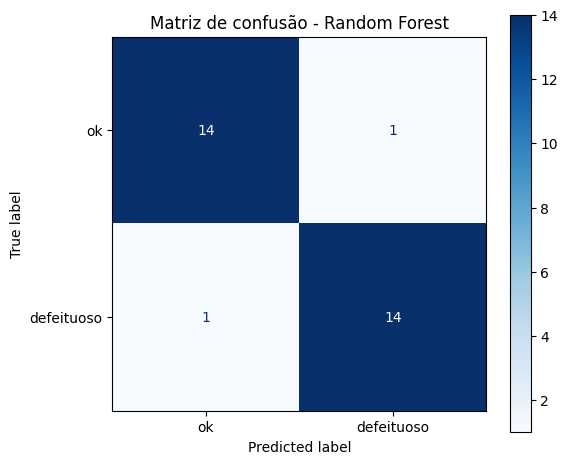

Matriz salva em: ..\outputs\matrizes_confusao\matriz_confusao_random_forest.png


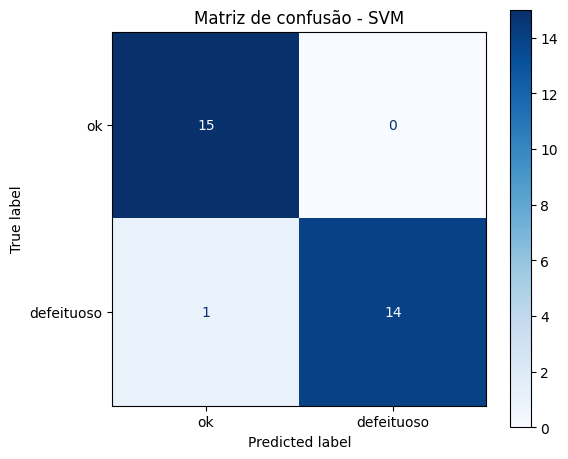

Matriz salva em: ..\outputs\matrizes_confusao\matriz_confusao_svm.png


In [11]:
for nome_modelo, y_pred_test in predicoes_teste.items():
    cm = confusion_matrix(
        y_test,
        y_pred_test,
        labels=["ok", "defeituoso"]
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["ok", "defeituoso"]
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d", cmap="Blues")
    plt.title(f"Matriz de confusão - {nome_modelo}")
    plt.tight_layout()
    
    nome_arquivo = f"matriz_confusao_{nome_modelo.replace(' ', '_').lower()}.png"
    caminho_saida = MATRIZES_DIR / nome_arquivo
    
    plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Matriz salva em: {caminho_saida}")

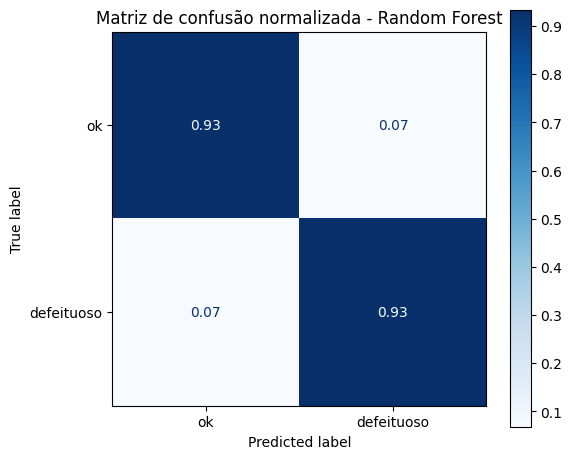

Matriz normalizada salva em: ..\outputs\matrizes_confusao\matriz_confusao_normalizada_random_forest.png


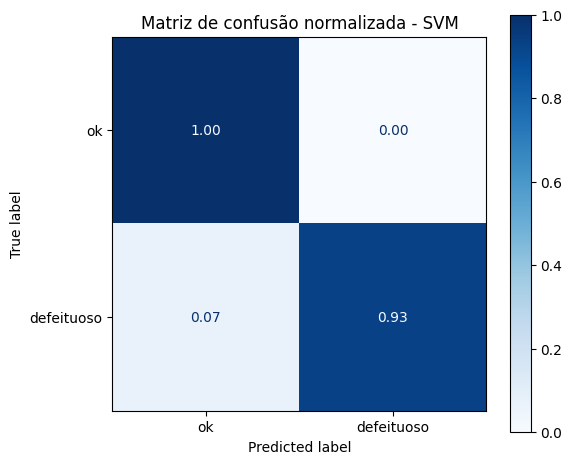

Matriz normalizada salva em: ..\outputs\matrizes_confusao\matriz_confusao_normalizada_svm.png


In [12]:
for nome_modelo, y_pred_test in predicoes_teste.items():
    cm_norm = confusion_matrix(
        y_test,
        y_pred_test,
        labels=["ok", "defeituoso"],
        normalize="true"
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["ok", "defeituoso"]
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format=".2f", cmap="Blues")
    plt.title(f"Matriz de confusão normalizada - {nome_modelo}")
    plt.tight_layout()
    
    nome_arquivo = f"matriz_confusao_normalizada_{nome_modelo.replace(' ', '_').lower()}.png"
    caminho_saida = MATRIZES_DIR / nome_arquivo
    
    plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Matriz normalizada salva em: {caminho_saida}")

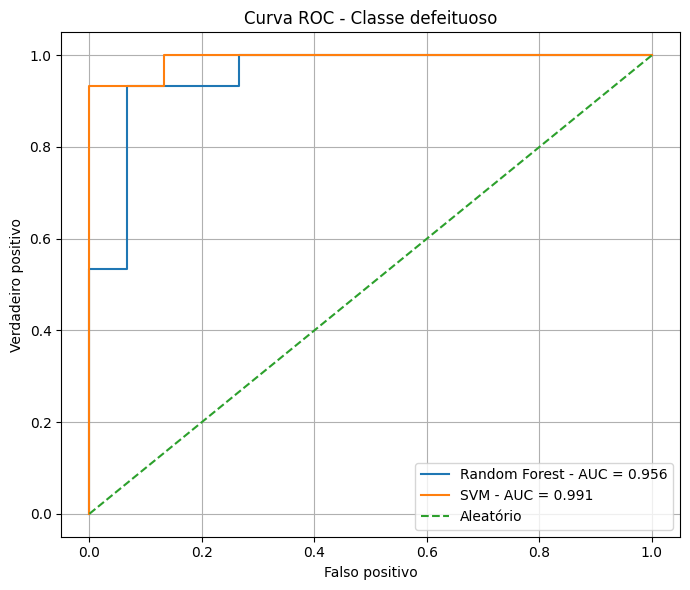

Curva ROC salva em: ..\outputs\metricas\curva_roc.png


In [13]:
plt.figure(figsize=(7, 6))

for nome_modelo, modelo in modelos.items():
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:, list(modelo.classes_).index("defeituoso")]
    else:
        continue
    
    y_test_bin = (y_test == "defeituoso").astype(int)
    
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{nome_modelo} - AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.xlabel("Falso positivo")
plt.ylabel("Verdadeiro positivo")
plt.title("Curva ROC - Classe defeituoso")
plt.legend()
plt.grid(True)
plt.tight_layout()

caminho_roc = METRICAS_DIR / "curva_roc.png"
plt.savefig(caminho_roc, dpi=150, bbox_inches="tight")
plt.show()

print(f"Curva ROC salva em: {caminho_roc}")

In [14]:
print(
    "Observação: a importância de variáveis abaixo é calculada com Random Forest "
    "apenas para interpretação das features. Isso não significa que o Random Forest "
    "foi o melhor classificador final."
)


Observação: a importância de variáveis abaixo é calculada com Random Forest apenas para interpretação das features. Isso não significa que o Random Forest foi o melhor classificador final.


,feature,importancia
25,glcm_contrast,0.136275
23,std_s,0.112635
13,mean_r,0.094824
21,mean_v,0.084331
14,mean_g,0.063899
15,mean_b,0.058780
27,glcm_energy,0.038629
26,glcm_homogeneity,0.037406
19,mean_h,0.037086
22,std_h,0.036442


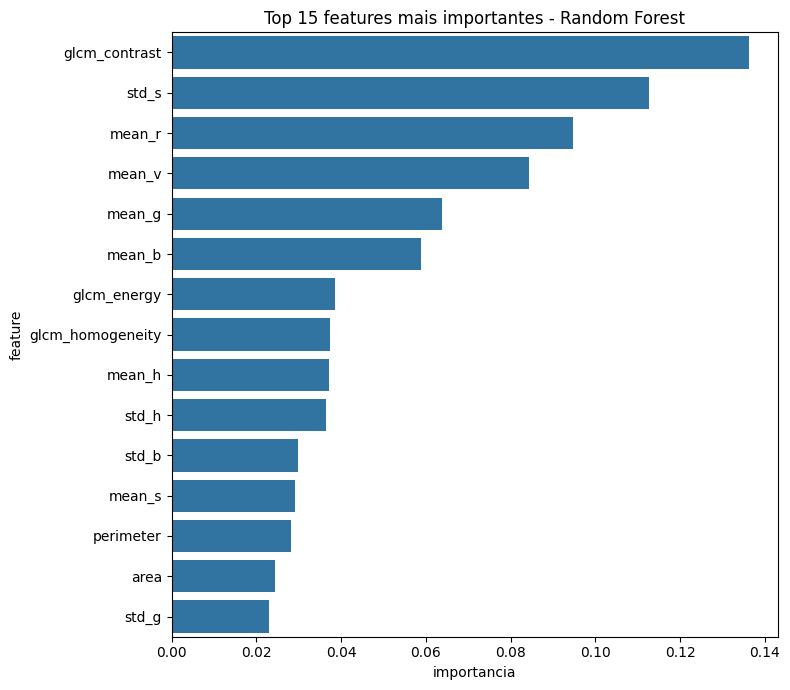

Gráfico salvo em: ..\outputs\graficos_features\importancia_features_random_forest.png


In [15]:
importancias = modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

display(df_importancias.head(20))

df_importancias.to_csv(
    GRAFICOS_DIR / "importancia_features_random_forest.csv",
    index=False
)

plt.figure(figsize=(8, 7))
sns.barplot(
    data=df_importancias.head(15),
    x="importancia",
    y="feature"
)
plt.title("Top 15 features mais importantes - Random Forest")
plt.tight_layout()

caminho_importancia = GRAFICOS_DIR / "importancia_features_random_forest.png"
plt.savefig(caminho_importancia, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {caminho_importancia}")

In [ ]:
# As células abaixo acrescentam três pontos importantes ao trabalho:

# 1. comparação entre grupos de features;
# 2. seleção/análise de features com SelectKBest e PCA;
# 3. ajuste simples de hiperparâmetros com GridSearchCV.

# Essas análises não substituem o pipeline obrigatório. Elas servem para justificar melhor quais características ajudam na separação entre grãos OK e defeituosos.

# Forma inclui descritores geométricos e momentos de Hu, pois ambos descrevem geometria/forma do objeto.
features_forma_base = [
    "area", "perimeter", "eccentricity", "solidity", "extent", "circularity"
]
features_hu = [col for col in X_train.columns if col.startswith("hu_")]
features_forma = features_forma_base + features_hu

# Cor: médias e desvios em RGB/HSV.
features_cor = [
    col for col in X_train.columns
    if col.startswith("mean_") or col.startswith("std_")
]

# Textura: propriedades GLCM.
features_textura = [
    col for col in X_train.columns
    if col.startswith("glcm_")
]

def manter_colunas_existentes(colunas):
    """Mantém apenas colunas existentes em X_train, evitando erro se algum nome mudar."""
    return list(dict.fromkeys([col for col in colunas if col in X_train.columns]))

grupos_features = {
    "forma": manter_colunas_existentes(features_forma),
    "cor": manter_colunas_existentes(features_cor),
    "textura": manter_colunas_existentes(features_textura),
    "cor + textura": manter_colunas_existentes(features_cor + features_textura),
    "cor + textura + forma": manter_colunas_existentes(features_cor + features_textura + features_forma),
    "todas": list(X_train.columns)
}

print("Quantidade de features por grupo:")
for grupo, cols in grupos_features.items():
    print(f"{grupo}: {len(cols)} features")

modelos_grupos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ])
}

resultados_grupos = []

for nome_grupo, colunas in grupos_features.items():
    if len(colunas) == 0:
        continue

    for nome_modelo, modelo in modelos_grupos.items():
        modelo.fit(X_train[colunas], y_train)
        y_pred = modelo.predict(X_test[colunas])

        resultados_grupos.append({
            "grupo_features": nome_grupo,
            "qtd_features": len(colunas),
            "modelo": nome_modelo,
            "accuracy_test": accuracy_score(y_test, y_pred),
            "precision_defeituoso_test": precision_score(y_test, y_pred, pos_label="defeituoso", zero_division=0),
            "recall_defeituoso_test": recall_score(y_test, y_pred, pos_label="defeituoso", zero_division=0),
            "f1_defeituoso_test": f1_score(y_test, y_pred, pos_label="defeituoso", zero_division=0),
            "erros_test": int((y_test != y_pred).sum())
        })

df_resultados_grupos = pd.DataFrame(resultados_grupos).sort_values(
    by=["erros_test", "f1_defeituoso_test", "accuracy_test"],
    ascending=[True, False, False]
)

display(df_resultados_grupos)

caminho_grupos = METRICAS_DIR / "comparacao_grupos_features.csv"
df_resultados_grupos.to_csv(caminho_grupos, index=False)

print(f"Tabela salva em: {caminho_grupos}")


Quantidade de features por grupo:
forma: 13 features
cor: 12 features
textura: 4 features
cor + textura: 16 features
cor + textura + forma: 29 features
todas: 29 features


c:\Users\henri\Desktop\Eng. Computação\7º Semestre\Visão Computacional\projeto-inspecao-cafe\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\henri\Desktop\Eng. Computação\7º Semestre\Visão Computacional\projeto-inspecao-cafe\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\henri\Desktop\Eng. Computação\7º Semestre\Visão Computacional\projeto-inspecao-cafe\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` inste

,grupo_features,qtd_features,modelo,accuracy_test,precision_defeituoso_test,recall_defeituoso_test,f1_defeituoso_test,erros_test
9,cor + textura + forma,29,SVM,0.966667,1.000000,0.933333,0.965517,1
11,todas,29,SVM,0.966667,1.000000,0.933333,0.965517,1
3,cor,12,SVM,0.933333,0.933333,0.933333,0.933333,2
8,cor + textura + forma,29,Random Forest,0.933333,0.933333,0.933333,0.933333,2
10,todas,29,Random Forest,0.933333,0.933333,0.933333,0.933333,2
7,cor + textura,16,SVM,0.933333,1.000000,0.866667,0.928571,2
6,cor + textura,16,Random Forest,0.900000,0.928571,0.866667,0.896552,3
2,cor,12,Random Forest,0.866667,0.866667,0.866667,0.866667,4
4,textura,4,Random Forest,0.866667,0.923077,0.800000,0.857143,4
5,textura,4,SVM,0.833333,0.857143,0.800000,0.827586,5


Tabela salva em: ..\outputs\metricas\comparacao_grupos_features.csv


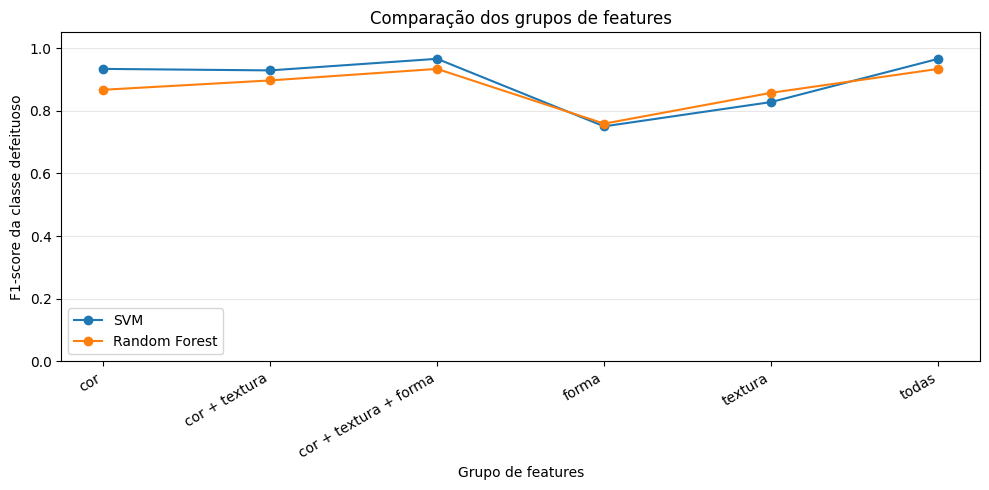

Gráfico salvo em: ..\outputs\graficos_features\comparacao_grupos_features.png


In [17]:
# Gráfico comparando os grupos de features pelo F1-score da classe defeituoso.

plt.figure(figsize=(10, 5))

for modelo in df_resultados_grupos["modelo"].unique():
    dados_modelo = df_resultados_grupos[df_resultados_grupos["modelo"] == modelo].copy()
    dados_modelo = dados_modelo.sort_values("grupo_features")
    plt.plot(
        dados_modelo["grupo_features"],
        dados_modelo["f1_defeituoso_test"],
        marker="o",
        label=modelo
    )

plt.xlabel("Grupo de features")
plt.ylabel("F1-score da classe defeituoso")
plt.title("Comparação dos grupos de features")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

caminho_grafico_grupos = GRAFICOS_DIR / "comparacao_grupos_features.png"
plt.savefig(caminho_grafico_grupos, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {caminho_grafico_grupos}")


,feature,score_f_classif,p_value,selecionada_top_k
23,std_s,92.437680,4.576320e-17,True
13,mean_r,74.971963,1.121498e-14,True
21,mean_v,74.963696,1.124544e-14,True
14,mean_g,56.721435,5.941630e-12,True
25,glcm_contrast,55.261996,1.007377e-11,True
15,mean_b,52.666690,2.603112e-11,True
28,glcm_correlation,20.915361,1.057470e-05,True
18,std_b,18.614875,3.029067e-05,True
17,std_g,13.935946,2.756939e-04,True
24,std_v,13.556565,3.312402e-04,True


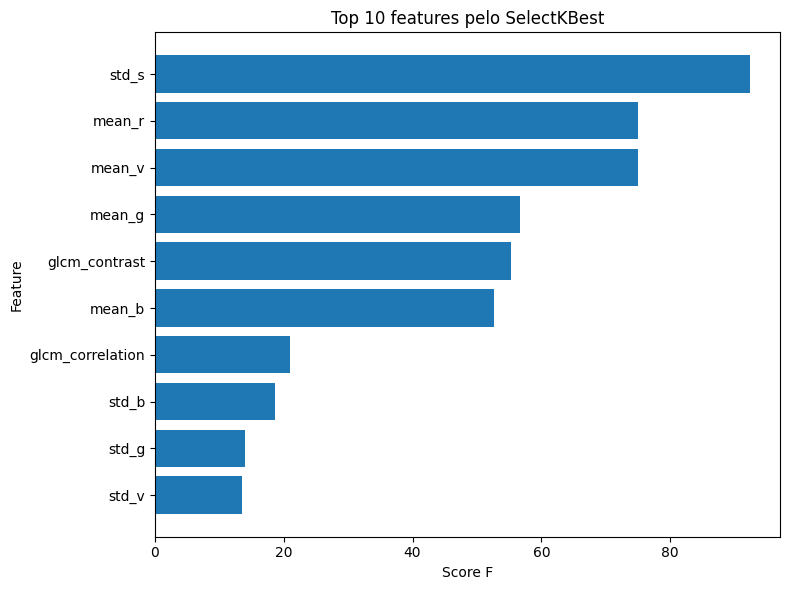

Tabela salva em: ..\outputs\graficos_features\selectkbest_features.csv
Gráfico salvo em: ..\outputs\graficos_features\selectkbest_top10.png


In [18]:
# ============================================================
# SelectKBest: seleção estatística das features mais relevantes
# ============================================================

k = min(10, X_train.shape[1])

pipeline_select = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=k))
])

pipeline_select.fit(X_train, y_train)

selector = pipeline_select.named_steps["select"]

df_selectkbest = pd.DataFrame({
    "feature": X_train.columns,
    "score_f_classif": selector.scores_,
    "p_value": selector.pvalues_,
    "selecionada_top_k": selector.get_support()
}).sort_values(by="score_f_classif", ascending=False)

display(df_selectkbest.head(15))

caminho_select = GRAFICOS_DIR / "selectkbest_features.csv"
df_selectkbest.to_csv(caminho_select, index=False)

plt.figure(figsize=(8, 6))
top_select = df_selectkbest.head(10).sort_values("score_f_classif")
plt.barh(top_select["feature"], top_select["score_f_classif"])
plt.xlabel("Score F")
plt.ylabel("Feature")
plt.title("Top 10 features pelo SelectKBest")
plt.tight_layout()

caminho_select_fig = GRAFICOS_DIR / "selectkbest_top10.png"
plt.savefig(caminho_select_fig, dpi=150, bbox_inches="tight")
plt.show()

print(f"Tabela salva em: {caminho_select}")
print(f"Gráfico salvo em: {caminho_select_fig}")


,PC1,PC2,classe,conjunto
0,1.435800,2.422575,defeituoso,treino
1,-1.474405,-0.376552,ok,treino
2,-3.263419,-2.544902,ok,treino
3,1.154760,2.951575,defeituoso,treino
4,-2.505445,-0.100744,ok,treino


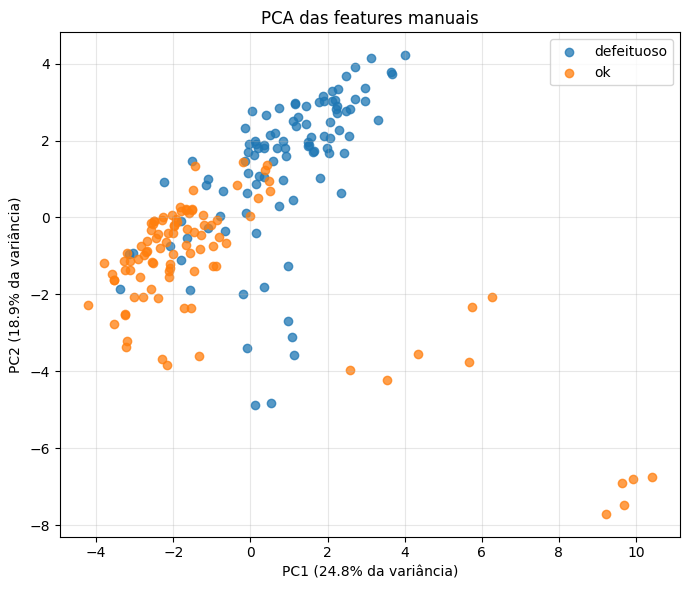

Gráfico salvo em: ..\outputs\graficos_features\pca_features.png
Variância explicada pelas duas primeiras componentes: 43.7%


In [19]:
# ============================================================
# PCA para visualização 2D das classes
# ============================================================

# O PCA é ajustado apenas no treino e depois aplicado nos conjuntos de treino, validação e teste.
pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42))
])

pipeline_pca.fit(X_train)

def transformar_pca(X_dados, y_dados, nome_split):
    comp = pipeline_pca.transform(X_dados)
    return pd.DataFrame({
        "PC1": comp[:, 0],
        "PC2": comp[:, 1],
        "classe": list(y_dados),
        "conjunto": nome_split
    })

df_pca = pd.concat([
    transformar_pca(X_train, y_train, "treino"),
    transformar_pca(X_val, y_val, "validacao"),
    transformar_pca(X_test, y_test, "teste")
], ignore_index=True)

pca = pipeline_pca.named_steps["pca"]
variancia_pc1 = pca.explained_variance_ratio_[0]
variancia_pc2 = pca.explained_variance_ratio_[1]

display(df_pca.head())

plt.figure(figsize=(7, 6))

for classe in df_pca["classe"].unique():
    dados_classe = df_pca[df_pca["classe"] == classe]
    plt.scatter(
        dados_classe["PC1"],
        dados_classe["PC2"],
        label=classe,
        alpha=0.75
    )

plt.xlabel(f"PC1 ({variancia_pc1:.1%} da variância)")
plt.ylabel(f"PC2 ({variancia_pc2:.1%} da variância)")
plt.title("PCA das features manuais")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

caminho_pca = GRAFICOS_DIR / "pca_features.png"
plt.savefig(caminho_pca, dpi=150, bbox_inches="tight")
plt.show()

df_pca.to_csv(GRAFICOS_DIR / "pca_features.csv", index=False)

print(f"Gráfico salvo em: {caminho_pca}")
print(f"Variância explicada pelas duas primeiras componentes: {(variancia_pc1 + variancia_pc2):.1%}")


In [20]:
# ============================================================
# Ajuste simples de hiperparâmetros com validação cruzada
# ============================================================

# Esta etapa ajuda a mostrar que os parâmetros dos modelos foram avaliados de forma mais sistemática.
# O teste continua sendo reservado para a avaliação final.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer_f1_defeituoso = make_scorer(f1_score, pos_label="defeituoso")

grid_svm = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(probability=True, random_state=42))
    ]),
    param_grid={
        "svm__kernel": ["rbf", "linear"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", "auto"]
    },
    scoring=scorer_f1_defeituoso,
    cv=cv,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    },
    scoring=scorer_f1_defeituoso,
    cv=cv,
    n_jobs=-1
)

grids = {
    "SVM ajustado": grid_svm,
    "Random Forest ajustado": grid_rf
}

resultados_ajuste = []

for nome, grid in grids.items():
    print("=" * 60)
    print(nome)
    print("=" * 60)

    grid.fit(X_train, y_train)

    print("Melhores parâmetros:")
    print(grid.best_params_)
    print("Melhor F1 médio na validação cruzada:", grid.best_score_)

    melhor_estimador = grid.best_estimator_
    y_pred_val_grid = melhor_estimador.predict(X_val)
    y_pred_test_grid = melhor_estimador.predict(X_test)

    resultados_ajuste.append({
        "modelo": nome,
        "melhores_parametros": str(grid.best_params_),
        "f1_medio_cv": grid.best_score_,
        "accuracy_val": accuracy_score(y_val, y_pred_val_grid),
        "f1_defeituoso_val": f1_score(y_val, y_pred_val_grid, pos_label="defeituoso", zero_division=0),
        "erros_val": int((y_val != y_pred_val_grid).sum()),
        "accuracy_test": accuracy_score(y_test, y_pred_test_grid),
        "precision_defeituoso_test": precision_score(y_test, y_pred_test_grid, pos_label="defeituoso", zero_division=0),
        "recall_defeituoso_test": recall_score(y_test, y_pred_test_grid, pos_label="defeituoso", zero_division=0),
        "f1_defeituoso_test": f1_score(y_test, y_pred_test_grid, pos_label="defeituoso", zero_division=0),
        "erros_test": int((y_test != y_pred_test_grid).sum())
    })

df_resultados_ajuste = pd.DataFrame(resultados_ajuste).sort_values(
    by=["erros_test", "f1_defeituoso_test", "accuracy_test"],
    ascending=[True, False, False]
)

display(df_resultados_ajuste)

caminho_ajuste = METRICAS_DIR / "ajuste_hiperparametros.csv"
df_resultados_ajuste.to_csv(caminho_ajuste, index=False)

print(f"Tabela salva em: {caminho_ajuste}")


SVM ajustado


c:\Users\henri\Desktop\Eng. Computação\7º Semestre\Visão Computacional\projeto-inspecao-cafe\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Melhores parâmetros:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Melhor F1 médio na validação cruzada: 0.9427330779054917
Random Forest ajustado
Melhores parâmetros:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Melhor F1 médio na validação cruzada: 0.9565365668813947


,modelo,melhores_parametros,f1_medio_cv,accuracy_val,f1_defeituoso_val,erros_val,accuracy_test,precision_defeituoso_test,recall_defeituoso_test,f1_defeituoso_test,erros_test
0,SVM ajustado,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.942733,1.000000,1.000000,0,0.966667,1.000000,0.933333,0.965517,1
1,Random Forest ajustado,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.956537,0.966667,0.965517,1,0.900000,0.928571,0.866667,0.896552,3


Tabela salva em: ..\outputs\metricas\ajuste_hiperparametros.csv


In [21]:
# Escolha final do melhor modelo obrigatório, usando primeiro a menor quantidade de erros,
# depois maior F1 da classe defeituoso e maior acurácia.
df_escolha_modelo = df_resultados_teste.sort_values(
    by=["erros_test", "f1_defeituoso_test", "accuracy_test"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(df_escolha_modelo)

melhor_nome = df_escolha_modelo.loc[0, "modelo"]
melhor_modelo = modelos[melhor_nome]
y_pred_melhor = predicoes_teste[melhor_nome]

print("Melhor modelo escolhido:", melhor_nome)
print("Critério: menor número de erros no teste; em caso de empate, maior F1 da classe defeituoso.")


,modelo,accuracy_test,precision_defeituoso_test,recall_defeituoso_test,f1_defeituoso_test,erros_test
0,SVM,0.966667,1.000000,0.933333,0.965517,1
1,Random Forest,0.933333,0.933333,0.933333,0.933333,2


Melhor modelo escolhido: SVM
Critério: menor número de erros no teste; em caso de empate, maior F1 da classe defeituoso.


In [22]:
def localizar_imagem(classe_real, filename):
    caminho_direto = DATASET_DIR / classe_real / filename
    
    if caminho_direto.exists():
        return caminho_direto
    
    encontrados = list((DATASET_DIR / classe_real).rglob(filename))
    
    if len(encontrados) > 0:
        return encontrados[0]
    
    return None

In [23]:
# Limpar erros antigos
for arquivo in ERROS_DIR.glob("*"):
    if arquivo.is_file():
        arquivo.unlink()

erros_df = df_test.copy()
erros_df["predito"] = y_pred_melhor
erros_df["acertou"] = erros_df["classe"] == erros_df["predito"]

erros_df = erros_df[erros_df["acertou"] == False]

print("Quantidade de erros:", len(erros_df))

if len(erros_df) == 0:
    arquivo_sem_erros = ERROS_DIR / "SEM_ERROS.txt"
    
    with open(arquivo_sem_erros, "w", encoding="utf-8") as f:
        f.write(f"O modelo {melhor_nome} não errou nenhuma imagem no conjunto de teste.\n")
    
    print("Nenhum erro encontrado. Arquivo SEM_ERROS.txt criado.")
else:
    for i, (_, linha) in enumerate(erros_df.iterrows(), start=1):
        filename = linha["filename"]
        classe_real = linha["classe"]
        classe_predita = linha["predito"]
        
        caminho_img = localizar_imagem(classe_real, filename)
        
        if caminho_img is None:
            print(f"Imagem não encontrada: classe={classe_real}, filename={filename}")
            continue
        
        img_bgr = cv2.imread(str(caminho_img))
        
        if img_bgr is None:
            print(f"Erro ao abrir imagem: {caminho_img}")
            continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Real: {classe_real} | Predito: {classe_predita}")
        
        nome_saida = f"erro_{i:02d}_{classe_real}_pred_{classe_predita}_{filename}.png"
        caminho_saida = ERROS_DIR / nome_saida
        
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        plt.close()
        
        print(f"Erro salvo: {caminho_saida}")

Quantidade de erros: 1
Erro salvo: ..\outputs\erros\erro_01_defeituoso_pred_ok_defeituoso_0042.jpg.png


In [24]:
erros_df[["filename", "classe", "predito"]].to_csv(
    ERROS_DIR / "tabela_erros.csv",
    index=False
)

display(erros_df[["filename", "classe", "predito"]])

,filename,classe,predito
141,defeituoso_0042.jpg,defeituoso,ok


In [25]:
print("Métricas:")
for arquivo in METRICAS_DIR.glob("*"):
    print("-", arquivo.name)

print("\nMatrizes de confusão:")
for arquivo in MATRIZES_DIR.glob("*"):
    print("-", arquivo.name)

print("\nErros:")
for arquivo in ERROS_DIR.glob("*"):
    print("-", arquivo.name)

print("\nGráficos:")
for arquivo in GRAFICOS_DIR.glob("*"):
    print("-", arquivo.name)

Métricas:
- ajuste_hiperparametros.csv
- comparacao_grupos_features.csv
- curva_roc.png
- metricas_teste.csv
- metricas_validacao.csv
- tabela_metricas.csv

Matrizes de confusão:
- matriz_confusao_normalizada_random_forest.png
- matriz_confusao_normalizada_svm.png
- matriz_confusao_random_forest.png
- matriz_confusao_svm.png
- matriz_Random_Forest.png
- matriz_SVM.png

Erros:
- erro_01_defeituoso_pred_ok_defeituoso_0042.jpg.png
- tabela_erros.csv

Gráficos:
- boxplot_circularity.png
- boxplot_glcm_contrast.png
- boxplot_glcm_homogeneity.png
- boxplot_mean_h.png
- boxplot_mean_s.png
- boxplot_mean_v.png
- boxplot_solidity.png
- boxplot_std_v.png
- comparacao_grupos_features.png
- importancia_features_random_forest.csv
- importancia_features_random_forest.png
- importancia_random_forest.png
- pca_features.csv
- pca_features.png
- selectkbest_features.csv
- selectkbest_top10.png
